In [43]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

In [45]:
image_ds = tf.data.Dataset.list_files("data/kitti/training/image_2/*.png", shuffle=False)
mask_ds = tf.data.Dataset.list_files("data/kitti/training/semantic/*.png", shuffle=False)
dataset = tf.data.Dataset.zip((image_ds, mask_ds))

In [46]:
for path in image_ds.take(5):
    print(path.numpy())

b'data/kitti/training/image_2/000000_10.png'
b'data/kitti/training/image_2/000001_10.png'
b'data/kitti/training/image_2/000002_10.png'
b'data/kitti/training/image_2/000003_10.png'
b'data/kitti/training/image_2/000004_10.png'


In [47]:
for path in mask_ds.take(5):
    print(path.numpy())

b'data/kitti/training/semantic/000000_10.png'
b'data/kitti/training/semantic/000001_10.png'
b'data/kitti/training/semantic/000002_10.png'
b'data/kitti/training/semantic/000003_10.png'
b'data/kitti/training/semantic/000004_10.png'


In [48]:
from data.devkit_semantics.devkit.helpers.labels import labels

mapping = np.full(256, 255, dtype=np.int32)
for label in labels:
    if label.id >= 0:
        mapping[label.id] = label.trainId
mapping[mapping == 255] = 19

In [49]:
def load_preprocess(image_path, mask_path):
    raw_image = tf.io.read_file(image_path)
    raw_mask = tf.io.read_file(mask_path)

    decoded_image = tf.image.decode_png(raw_image, channels=3)
    decoded_mask = tf.image.decode_png(raw_mask, channels=1)

    resized_image = tf.image.resize(decoded_image, [368,1232])
    resized_mask = tf.image.resize(decoded_mask, [368,1232], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

    label_mapping = tf.constant(mapping, dtype=tf.int32)
    resized_mask = tf.gather(label_mapping, tf.cast(resized_mask, tf.int32))

    resized_image = resized_image / 255.0

    return resized_image, resized_mask

In [50]:
dataset = dataset.map(load_preprocess)

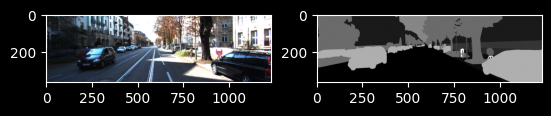

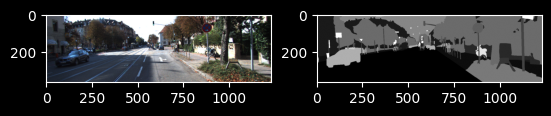

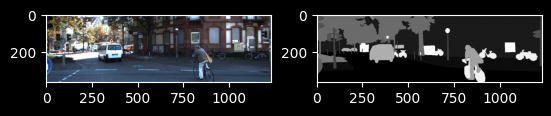

In [51]:
for feature, label in dataset.take(3):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    ax1.imshow(feature)
    ax2.imshow(tf.squeeze(label), cmap='gray')
    plt.show()

In [52]:
train_ds = dataset.take(160).shuffle(160).batch(4).prefetch(tf.data.AUTOTUNE)
val_ds = dataset.skip(160).batch(4).prefetch(tf.data.AUTOTUNE)

In [53]:
import importlib
import unet
importlib.reload(unet)
from unet import build_unet

In [54]:
model = build_unet((368, 1232, 3), 20)
model.summary()

Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 368, 1232, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 368, 1232, │      1,792 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 368, 1232, │     36,928 │ conv2d_43[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 184, 616,  │          0 │ conv2d_44[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 184, 616,  │     73,856 │ max_pooling2d_12… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 184, 616,  │    147,584 │ conv2d_45[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 92, 308,   │          0 │ conv2d_46[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, 92, 308,   │    295,168 │ max_pooling2d_13… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_48 (Conv2D)  │ (None, 92, 308,   │    590,080 │ conv2d_47[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 46, 154,   │          0 │ conv2d_48[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_49 (Conv2D)  │ (None, 46, 154,   │  1,180,160 │ max_pooling2d_14… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_50 (Conv2D)  │ (None, 46, 154,   │  2,359,808 │ conv2d_49[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 23, 77,    │          0 │ conv2d_50[0][0]   │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_51 (Conv2D)  │ (None, 23, 77,    │  4,719,616 │ max_pooling2d_15… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 23, 77,    │  9,438,208 │ conv2d_51[0][0]   │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, 46, 154,   │  2,097,664 │ conv2d_52[0][0]   │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 46, 154,   │          0 │ conv2d_transpose

 Total params: 31,032,980 (118.38 MB)

 Trainable params: 31,032,980 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [56]:
history = model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 200s 5s/step - accuracy: 0.2091 - loss: 2.5809 - val_accuracy: 0.3780 - val_loss: 2.2392
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 262s 7s/step - accuracy: 0.4381 - loss: 2.0202 - val_accuracy: 0.4413 - val_loss: 2.1258
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 291s 7s/step - accuracy: 0.5049 - loss: 1.7440 - val_accuracy: 0.5132 - val_loss: 1.7868
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 294s 7s/step - accuracy: 0.5529 - loss: 1.6126 - val_accuracy: 0.5656 - val_loss: 1.6837
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 295s 7s/step - accuracy: 0.6038 - loss: 1.4091 - val_accuracy: 0.5932 - val_loss: 1.4868


In [57]:
for image, mask in dataset.take(1):
    print(np.unique(mask.numpy()))

[ 0  1  2  3  4  5  7  8 10 11 13 14 15 19]


In [68]:
model.save('checkpoints/baseline_unet_5epochs.keras')